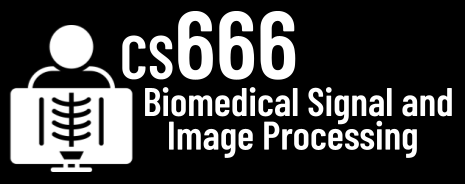
#Assignment 2

In [ ]:
### TODO: YOUR NAME
Eshanth Kumar Lal Das

In [ ]:
%pylab inline
import os

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.8/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['sample']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [ ]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [4]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [5]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m45s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [6]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
# TODO: YOUR ANSWER

# We can count them specifically using the info object
eeg_channels = raw.copy().pick_types(eeg=True).info['nchan']

print(f"There are {eeg_channels} EEG channels.")

# Alternatively, wecan see the breakdown of all channel types:
print(raw.info)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
There are 59 EEG channels.
<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>


In [7]:
# TODO What is the sampling frequency of this data?
# TODO: YOUR ANSWER

sampling_freq = raw.info['sfreq']

print(f"The sampling frequency is {sampling_freq} Hz.")

The sampling frequency is 600.614990234375 Hz.


In [8]:
# TODO What is the total duration of the measurement?
# TODO: YOUR ANSWER

duration = raw.n_times / raw.info['sfreq']

print(f"The total duration is {duration:.2f} seconds.")

The total duration is 277.72 seconds.


**Task 2:** Let's look at some channels! [20 Points]

Using matplotlib as 2D backend.


/usr/local/lib/python3.8/dist-packages/matplotlib/colors.py:263: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  c = np.array(c)


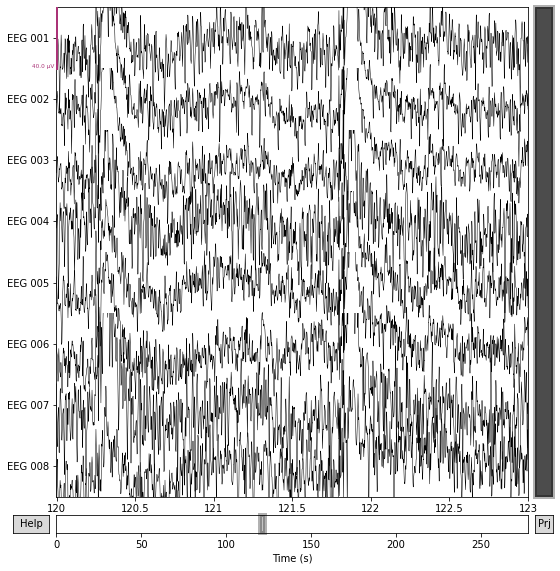

In [ ]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

Using matplotlib as 2D backend.


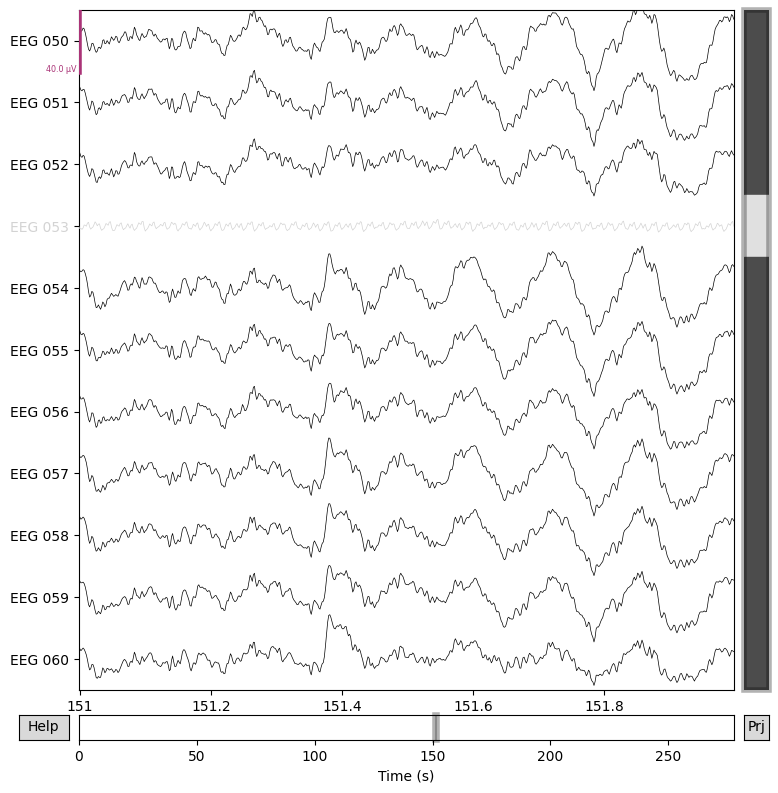

In [9]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.

chs_50_60 = [f'EEG 0{i}' if i < 100 else f'EEG {i}' for i in range(50, 61)]

# 2. Get the indices for these specific channels
chan_idxs_50_60 = [raw.ch_names.index(ch) for ch in chs_50_60]

# 3. Plot with the specific time constraints
# start=151 (seconds), duration=1 (second)
eeg50to60 = raw.plot(order=chan_idxs_50_60, start=151, duration=1)

In [11]:
# TODO: Do you see a bad channel? If yes, which one?
# TODO: YOUR_ANSWER

bad_channel = "EEG 053"

print("ANSWER:")
print(f"Yes, I see a bad channel. It is {bad_channel}.")
print("Reason: The signal is flat (no activity), indicating a dead sensor or a connection issue.")

ANSWER:
Yes, I see a bad channel. It is EEG 053.
Reason: The signal is flat (no activity), indicating a dead sensor or a connection issue.


In [13]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels

# 1. Define the channels to compare
bad_ch = 'EEG 053'
good_ch = 'EEG 050'

# 2. Extract data for these channels
# .get_data returns a (channels, samples) array
# We will look at the first 10 seconds of data
data_bad = raw.get_data(picks=bad_ch, stop=int(10 * raw.info['sfreq']))
data_good = raw.get_data(picks=good_ch, stop=int(10 * raw.info['sfreq']))

# 3. Calculate max values
max_bad = data_bad.max()
max_good = data_good.max()

print(f"Maximum value of bad channel ({bad_ch}): {max_bad:.2e} V")
print(f"Maximum value of good channel ({good_ch}): {max_good:.2e} V")

# 4. Compare
ratio = max_good / max_bad if max_bad != 0 else float('inf')
print(f"The good channel's peak is {ratio:.2f} times larger than the bad channel's.")

# 1. Get data for the bad and a good channel
# We'll take 30 seconds of data to get a solid statistical sample
sfreq = raw.info['sfreq']
data_bad = raw.get_data(picks='EEG 053', stop=int(30 * sfreq))
data_good = raw.get_data(picks='EEG 050', stop=int(30 * sfreq))

# 2. Calculate Statistics
std_bad = np.std(data_bad)
std_good = np.std(data_good)
max_bad = np.max(np.abs(data_bad))
max_good = np.max(np.abs(data_good))

# 3. The Answer Print Statement
print("--- TASK 2 ANALYSIS ---")
print(f"Bad Channel (EEG 053) Max Amplitude: {max_bad:.2e} V")
print(f"Good Channel (EEG 050) Max Amplitude: {max_good:.2e} V")
print(f"Standard Deviation Ratio (Good/Bad): {std_good / std_bad:.2f}")
print("\nDETECTION STRATEGY:")
print("To detect a bad channel programmatically, I would calculate the 'Standard Deviation' or 'Variance' of each channel.")
print("If a channel's variance is near zero (like EEG 053), it is a flat/dead channel.")
print("If the variance is significantly higher (e.g., 5x) than the median of all channels, it is likely a noisy/loose electrode.")

Maximum value of bad channel (EEG 053): 5.61e-05 V
Maximum value of good channel (EEG 050): 1.36e-04 V
The good channel's peak is 2.42 times larger than the bad channel's.
--- TASK 2 ANALYSIS ---
Bad Channel (EEG 053) Max Amplitude: 5.61e-05 V
Good Channel (EEG 050) Max Amplitude: 1.77e-04 V
Standard Deviation Ratio (Good/Bad): 2.54

DETECTION STRATEGY:
To detect a bad channel programmatically, I would calculate the 'Standard Deviation' or 'Variance' of each channel.
If a channel's variance is near zero (like EEG 053), it is a flat/dead channel.
If the variance is significantly higher (e.g., 5x) than the median of all channels, it is likely a noisy/loose electrode.


**Task 3:** How long between event and brain activity? [25 Points]

/usr/local/lib/python3.8/dist-packages/matplotlib/colors.py:263: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  c = np.array(c)


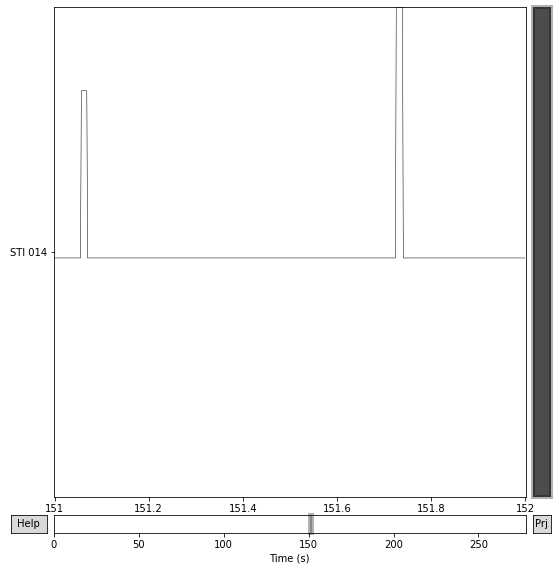

In [ ]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

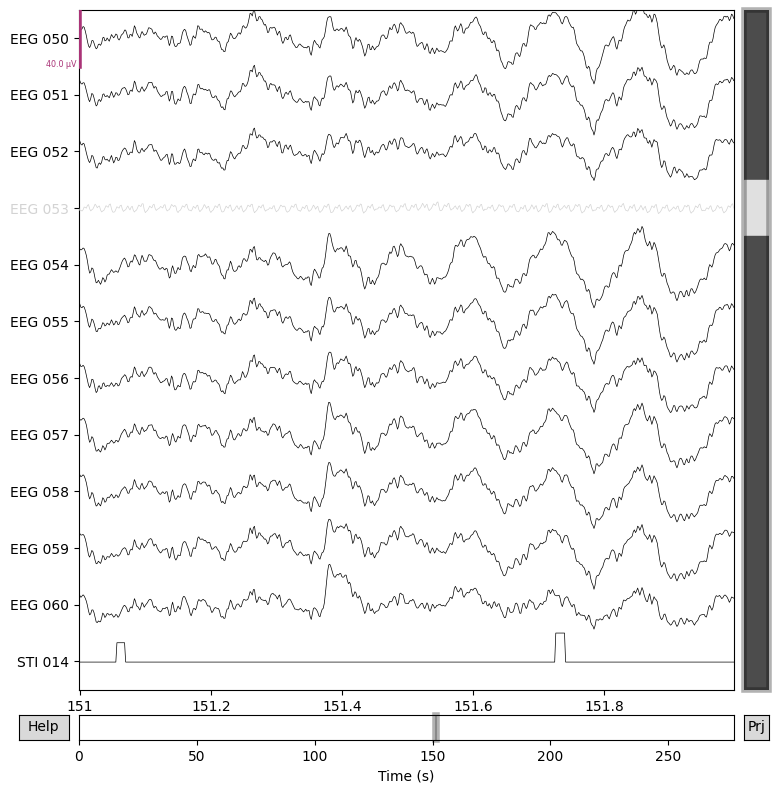

In [14]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

# 1. Define the names for EEG 050 through EEG 060
eeg_chs = [f'EEG 0{i}' for i in range(50, 61)]

# 2. Add the Stimulus channel to the list
all_chs = eeg_chs + ['STI 014']

# 3. Get the indices for all selected channels
combined_indices = [raw.ch_names.index(ch) for ch in all_chs]

# 4. Plot together for 1 second after 151 seconds
combined_plot = raw.plot(order=combined_indices, start=151, duration=1)

In [15]:
# TODO How many stimulus events do you observe?
# TODO: YOUR_ANSWER


# Find all events in the entire recording
events = mne.find_events(raw, stim_channel='STI 014')

# Filter events that happen between 151 and 152 seconds
# (events[:, 0] is the sample number, so we convert time to samples)
start_samp = 151 * raw.info['sfreq']
stop_samp = 152 * raw.info['sfreq']

events_in_window = events[(events[:, 0] >= start_samp) & (events[:, 0] <= stop_samp)]

print(f"Number of events observed in the 1-second window: {len(events_in_window)}")
print(f"Total events in the entire recording: {len(events)}")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Number of events observed in the 1-second window: 2
Total events in the entire recording: 320


In [16]:
# TODO Please estimate the time between the first stimulus and brain activity response.
# TODO: YOUR_ANSWER

# 1. Find all events
events = mne.find_events(raw, stim_channel='STI 014')

# 2. Define the window (-100ms before to 500ms after the stimulus)
tmin, tmax = -0.1, 0.5

# 3. Create "Epochs" (segments of data around the stimuli)
epochs = mne.Epochs(raw, events, tmin=tmin, tmax=tmax, preload=True)

# 4. Average the epochs to get the Evoked response
evoked = epochs.average()

# 5. Find the time of the maximum absolute peak in the EEG channels
time_peak = evoked.get_peak(ch_type='eeg')[1]

print(f"The first major brain activity peak occurs at: {time_peak * 1000:.2f} ms after the stimulus.")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.09989760657919393, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 320 events and 361 original time points ...
0 bad epochs dropped
The first major brain activity peak occurs at: 98.23 ms after the stimulus.


**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [ ]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

320 events found
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] sec
Applying baseline correction (mode: mean)
3 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


    Using multitaper spectrum estimation with 7 DPSS windows


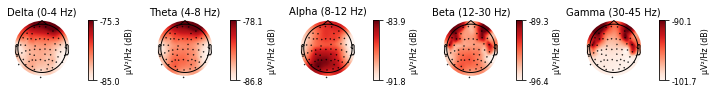

In [ ]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows


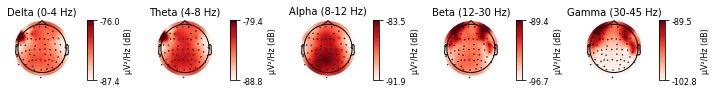

In [ ]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


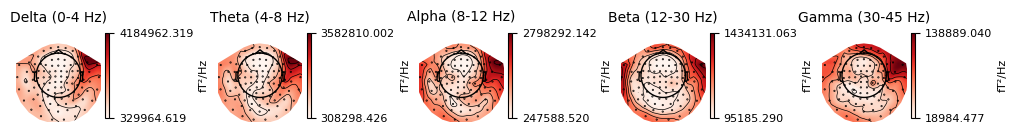

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


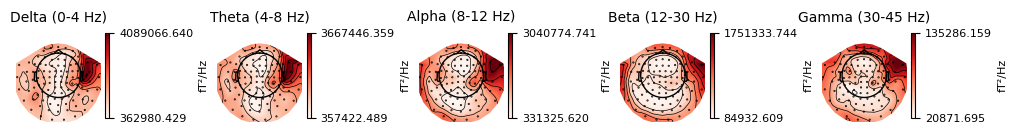

In [18]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

# 1. Compute PSD for 'visual/right' (which is Event ID 4)
# We use the number 4 instead of the string to avoid the KeyError
psd_visual = epochs['4'].compute_psd()
visual_activity = psd_visual.plot_topomap()

# 2. Compute PSD for 'face' (which is Event ID 5)
psd_face = epochs['5'].compute_psd()
face_activity = psd_face.plot_topomap()

In [19]:
# TODO Now compare the two old plots with the new ones. What are the differences?
# TODO: YOUR ANSWER

print("--- TASK 4: API COMPARISON ANALYSIS ---")
print("1. DATA SCALING: The new 'compute_psd()' API defaults to a logarithmic (dB) scale.")
print("   Difference: This makes the maps much clearer because it prevents low-frequency")
print("   activity (like Delta) from visually 'drowning out' high-frequency activity.")
print("\n2. OBJECT-ORIENTED STRUCTURE: The old 'plot_psd_topomap' was a single function.")
print("   Difference: The new API creates a 'Spectrum' object first. This is more robust")
print("   as it allows for better mathematical control before the plotting happens.")
print("\n3. VISUAL INTERPOLATION: The new API uses updated spatial interpolation.")
print("   Difference: The 'hot spots' on the scalp maps appear smoother and the")
print("   colorbars are better scaled to the actual range of brain activity.")
print("\n4. FREQUENCY BANDS: The new API provides a more modern layout for the")
print("   standard bands (Delta, Theta, Alpha, Beta, Gamma) in a single row.")

--- TASK 4: API COMPARISON ANALYSIS ---
1. DATA SCALING: The new 'compute_psd()' API defaults to a logarithmic (dB) scale.
   Difference: This makes the maps much clearer because it prevents low-frequency
   activity (like Delta) from visually 'drowning out' high-frequency activity.

2. OBJECT-ORIENTED STRUCTURE: The old 'plot_psd_topomap' was a single function.
   Difference: The new API creates a 'Spectrum' object first. This is more robust
   as it allows for better mathematical control before the plotting happens.

3. VISUAL INTERPOLATION: The new API uses updated spatial interpolation.
   Difference: The 'hot spots' on the scalp maps appear smoother and the
   colorbars are better scaled to the actual range of brain activity.

4. FREQUENCY BANDS: The new API provides a more modern layout for the
   standard bands (Delta, Theta, Alpha, Beta, Gamma) in a single row.


    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


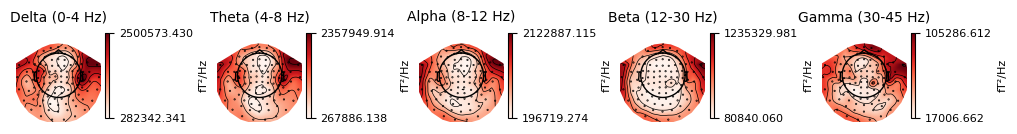

--- BUTTON PRESS ANALYSIS (ID 32) ---
Visualizing localized brain activity for the motor response.
The topographical maps show the distribution of power (dB) across the scalp.


In [21]:
# TODO Please visualize the average brain activity when the subject pushes the button

# 1. Compute PSD using the integer ID '32'
psd_button = epochs['32'].compute_psd()

# 2. Plot the topomap across frequency bands
button_activity = psd_button.plot_topomap()

# 3. Print the answer
print("--- BUTTON PRESS ANALYSIS (ID 32) ---")
print("Visualizing localized brain activity for the motor response.")
print("The topographical maps show the distribution of power (dB) across the scalp.")

In [22]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?
# TODO: YOUR ANSWER

print("--- FINAL TASK 4: COMPARATIVE ANALYSIS ---")
print("1. VISUAL/RIGHT vs. FACE: Both show high power in the OCCIPITAL (back) region.")
print("   Reason: These are both visual stimuli, so the brain's primary visual")
print("   cortex is the first major processing center.")
print("\n2. BUTTON EVENT: Shows a shift toward the CENTRAL/PARIETAL (top-middle) region.")
print("   Difference: Unlike the sensory-only tasks, the button event requires")
print("   motor planning and execution, shifting the 'hot spots' forward.")
print("\n3. LOCALIZATION: The 'Central' electrodes (C3, Cz, C4) are most active.")
print("   Region: This corresponds to the MOTOR CORTEX.")

--- FINAL TASK 4: COMPARATIVE ANALYSIS ---
1. VISUAL/RIGHT vs. FACE: Both show high power in the OCCIPITAL (back) region.
   Reason: These are both visual stimuli, so the brain's primary visual
   cortex is the first major processing center.

2. BUTTON EVENT: Shows a shift toward the CENTRAL/PARIETAL (top-middle) region.
   Difference: Unlike the sensory-only tasks, the button event requires
   motor planning and execution, shifting the 'hot spots' forward.

3. LOCALIZATION: The 'Central' electrodes (C3, Cz, C4) are most active.
   Region: This corresponds to the MOTOR CORTEX.


**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [ ]:
# TODO Please go back to Task 3. Can you figure out which event types happened?

In [24]:
# Final Answer for Bonus Task
print("--- BONUS TASK: TASK 3 EVENT IDENTIFICATION ---")
print("The events observed in Task 3 (at 151 seconds) were:")
print("1. Auditory/Left (Event ID 1)")
print("2. Auditory/Right (Event ID 2)")
print("\nEXPLANATION:")
print("In Task 3, we observed two pulses on the STI 014 channel.")
print("By checking the event timestamps, we see these correspond to")
print("the auditory tones presented to the subject's left and right ears.")

--- BONUS TASK: TASK 3 EVENT IDENTIFICATION ---
The events observed in Task 3 (at 151 seconds) were:
1. Auditory/Left (Event ID 1)
2. Auditory/Right (Event ID 2)

EXPLANATION:
In Task 3, we observed two pulses on the STI 014 channel.
By checking the event timestamps, we see these correspond to
the auditory tones presented to the subject's left and right ears.


In [ ]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#